# Input-calibration plotter

Compares FC telemetry (MAVSDK Position/Quaternion/Velocity/IMU) and Gazebo
ground-truth poses against the commanded attitude-rate + thrust profile sent
by `record_input_calibration.py`.

Modeled after `~/ws/scripts/soft_precise_landing/plotter_input_calibration.ipynb`
but reads from `PX4_Gazebo/calibration_data/input/<timestamp>/`.

Frame conventions (world positions/velocities in PX4 NED; **all body quantities in body-FRD**):
- **W** = world, NED (x=North, y=East, z=Down) — PX4 native; Gazebo ENU is converted via `NED_from_ENU`
- **B / I** = body, FRD (Forward/Right/Down) — PX4 native and MAVSDK PositionBody; Gazebo FLU is converted via `FRD_2_FLU = DCM(x=180°)`

### Manuscript IBVS terminology (only `w` shows up in this notebook)

The PLASMC manuscript uses `s`, `ṡ`, `h`, `w` for the IBVS image-plane quantities (see the output-calibration plotter for the full glossary). This input-calibration plotter deals with physical UAV **body-FRD** quantities — position, velocity, acceleration, angular velocity, thrust.

**Angular velocity — frame note (corrected):** the camera frame **is** body-FRD (axes aligned, no rotation between them), but the manuscript’s `w` is the *virtual image* angular velocity — the body rate expressed in the gravity-**leveled** virtual frame **V**. `R_{V←body}` is the roll/pitch **leveling** rotation, which is **identity only when the drone is level** (≠ I under tilt). So body-FRD ω equals the manuscript `w` only at zero tilt; in general they differ. *(The earlier claim that they are equal “because `R_V_from_body = I` after the SDF + cv2 chain” was wrong — that conflates camera=body, which holds, with V=body, which does not.)* Like the reference `~/ws/.../plotter_input_calibration.ipynb`, this notebook stays in the natural **body-FRD** frame — that is what the gyro measures and what `record_input_calibration.py` commands — so the rows below are body-FRD physical rates, not leveled-frame `w`:

| Variable | Quantity (body-FRD) |
|---|---|
| `B_w_ug` (GT-derived UAV body ω, FRD) | body angular velocity, ground truth |
| `w_t` (IMU body ω, FRD) | body angular velocity, measured by PX4 IMU |
| `w_u` (commanded body rate, FRD) | commanded body angular velocity |
| `B_w_ut` (TEL body ω, FRD via MAVSDK) | body angular velocity, post-EKF |

(These coincide with the manuscript’s virtual-image `w` only when level.) Position, linear velocity, and acceleration plots are body-FRD physical quantities — they don’t reuse `s` or `h` (those are image-plane).

In [1]:
import os, ast
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter as sgf
from ahrs import Quaternion, DCM

np.set_printoptions(precision=2, suppress=True)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Pick a run directory.
#  - Default: most recent valid run in calibration_data/input/ (RUN_INDEX = 0).
#  - Set RUN_INDEX = 1 for the previous run, 2 for the one before, ...
#    The picker prints the top N candidates so you can see what you're
#    selecting; pick by index.
#  - The picker also scans sibling INPUT-cal directories under calibration_data/
#    (basename starting with one of INPUT_ARCHIVE_PREFIXES, e.g. input_KMfix/,
#    input_yawgain/), so archived input-cal runs stay accessible by RUN_INDEX
#    without copying files around. Output-cal (output*/) and other cal dirs
#    (rollpitch_cal_*, yawagg_cal_*) are intentionally EXCLUDED so this
#    notebook only exposes input-calibration data — widen INPUT_ARCHIVE_PREFIXES
#    below if you want those visible too.
#  - To inspect a specific path instead, set RUN_DIR_OVERRIDE in a cell
#    BELOW this one, e.g.
#       RUN_DIR_OVERRIDE = '/home/shubham/.../input_archive_foo/Sun May 31 10-26-32 2026'
#    Setting it to None (or not defining it) falls back to RUN_INDEX.
RUN_INDEX = 0     # 0 = latest, 1 = previous, 2 = one before that, ...
N_SHOW    = 8     # how many recent valid runs to print

PARENT = '/home/shubham/Soft-Precise-Landing/PX4_Gazebo/calibration_data/input'

# Restrict archive discovery to INPUT-calibration data only: a sibling dir under
# calibration_data/ is scanned only if its basename starts with one of these.
# (Excludes output*/, rollpitch_cal_*, yawagg_cal_*, etc.) Add a prefix to widen.
INPUT_ARCHIVE_PREFIXES = ('input',)

# Tunable validity thresholds. Override before _is_valid_run is called if needed.
RUN_VALIDITY = dict(
    min_duration_s = 5.0,   # reject if gt['Time'] span < this (catches junk / negative-
                            #   duration recordings where the writer aborted mid-run)
    min_samples    = 200,   # reject if gt['Time'] sample count below this
)

def _is_valid_run(parent, d):
    """Valid = Telemetry_Data.npy + Ground_Truth.npy exist AND gt['Time']
    spans at least RUN_VALIDITY['min_duration_s'] forward seconds with
    RUN_VALIDITY['min_samples'] samples. Permissive on Img_Data.npy
    (often absent for pure attitude-rate cal)."""
    full = os.path.join(parent, d)
    if not os.path.isdir(full):
        return False
    if not os.path.isfile(os.path.join(full, 'Telemetry_Data.npy')):
        return False
    if not os.path.isfile(os.path.join(full, 'Ground_Truth.npy')):
        return False
    try:
        _gt = np.load(os.path.join(full, 'Ground_Truth.npy'), allow_pickle=True).item()
        _t = np.array(_gt.get('Time', []))
        if len(_t) < RUN_VALIDITY['min_samples']:
            return False
        if (_t[-1] - _t[0]) < RUN_VALIDITY['min_duration_s']:
            return False
        if 'Command' not in _gt or len(_gt['Command']) < 10:
            return False
        return True
    except Exception:
        return False

# Collect (full_path, mtime, source_label) for every valid INPUT-cal run we can
# find: the main PARENT directory, plus any sibling under calibration_data/
# whose name starts with one of INPUT_ARCHIVE_PREFIXES (input-cal data only).
def _collect_runs():
    runs = []
    for d in os.listdir(PARENT):
        full = os.path.join(PARENT, d)
        if _is_valid_run(PARENT, d):
            runs.append((full, os.path.getmtime(full), 'input'))
    archive_root = os.path.dirname(PARENT)
    for sub in sorted(os.listdir(archive_root)):
        if sub == 'input':                      # main PARENT already scanned above
            continue
        if not sub.startswith(INPUT_ARCHIVE_PREFIXES):   # input-cal data only
            continue
        sub_full = os.path.join(archive_root, sub)
        if not os.path.isdir(sub_full): continue
        for d in os.listdir(sub_full):
            if _is_valid_run(sub_full, d):
                full = os.path.join(sub_full, d)
                runs.append((full, os.path.getmtime(full), sub))
    return sorted(runs, key=lambda r: -r[1])      # most recent first

_runs = _collect_runs()
if not _runs:
    raise FileNotFoundError(
        f'No valid recordings found under {PARENT} or its input-cal sibling archives.')

print(f'Available runs (most recent first; pick via RUN_INDEX):')
import datetime as _dt
for i, (full, mt, src) in enumerate(_runs[:N_SHOW]):
    mark = ' <-- CURRENT' if i == RUN_INDEX else ''
    when = _dt.datetime.fromtimestamp(mt).strftime('%Y-%m-%d %H:%M:%S')
    print(f'  [{i}] {when}  {src:30s}  {os.path.basename(full)}{mark}')
if len(_runs) > N_SHOW:
    print(f'  ... and {len(_runs) - N_SHOW} older runs')

# Resolve RUN_DIR fresh every cell run so changing RUN_INDEX takes effect.
# To inspect a specific path instead, set RUN_DIR_OVERRIDE in a cell BELOW this
# one (e.g. RUN_DIR_OVERRIDE = '/path/to/archive/run'). Leave it unset/None to
# use RUN_INDEX.
RUN_DIR_OVERRIDE = globals().get('RUN_DIR_OVERRIDE', None)
if RUN_DIR_OVERRIDE:
    RUN_DIR = RUN_DIR_OVERRIDE
else:
    if RUN_INDEX >= len(_runs):
        raise IndexError(
            f'RUN_INDEX={RUN_INDEX} out of range; only {len(_runs)} valid runs found.')
    RUN_DIR = _runs[RUN_INDEX][0]
print(f'\nLoading from: {RUN_DIR}')

tel  = np.load(f'{RUN_DIR}/Telemetry_Data.npy', allow_pickle=True)[()]
gt   = np.load(f'{RUN_DIR}/Ground_Truth.npy',   allow_pickle=True)[()]
try:
    img = np.load(f'{RUN_DIR}/Img_Data.npy', allow_pickle=True)[()]
except FileNotFoundError:
    img = None

print('tel keys:', list(tel.keys()))
print('gt  keys:', list(gt.keys()))
print(f'gt samples: {len(gt["Time"])}, duration {gt["Time"][-1] - gt["Time"][0]:.2f}s')


Available runs (most recent first; pick via RUN_INDEX):
  [0] 2026-06-01 21:56:33  input                           Mon Jun  1 21-55-41 2026 <-- CURRENT
  [1] 2026-06-01 17:47:28  input                           Mon Jun  1 17-46-35 2026
  [2] 2026-06-01 17:44:34  input                           Mon Jun  1 17-43-38 2026
  [3] 2026-06-01 17:43:33  input                           Mon Jun  1 17-42-37 2026
  [4] 2026-06-01 17:42:32  input                           Mon Jun  1 17-41-36 2026
  [5] 2026-06-01 17:39:36  input                           Mon Jun  1 17-38-36 2026
  [6] 2026-05-31 10:59:59  input                           Sun May 31 10-58-31 2026
  [7] 2026-05-31 10:56:55  input                           Sun May 31 10-55-33 2026

Loading from: /home/shubham/Soft-Precise-Landing/PX4_Gazebo/calibration_data/input/Mon Jun  1 21-55-41 2026
tel keys: ['Position Body', 'Quaternion', 'Velocity Body', 'Angular Velocity Body', 'Odometry Timestamp', 'Acceleration', 'Angular Velocity FRD', 'IMU 

## §1 — Data preparation

Frame conventions, telemetry (MAVSDK), IMU, ground truth (Gazebo `/pose`), and the
commanded body-rate/thrust — all aligned to body-FRD / NED. (`BODY_YAW_SOURCE=gt` here for analysis.)

### Frame conventions

In [3]:
FRD_2_FLU    = np.array(DCM(x=180.0))                           # FRD ↔ FLU (self-inverse)
FLU_2_FRD    = FRD_2_FLU                                        # alias for the same DCM
NED_from_ENU = np.array([[0.0, 1.0, 0.0],
                          [1.0, 0.0, 0.0],
                          [0.0, 0.0, -1.0]])                     # NED ↔ ENU (self-inverse)
mass = 2.114   # kg, Holybro X500 (matches MATLAB Constants.m)
g_scalar = 9.8

### Telemetry data (MAVSDK)

PositionBody / Quaternion / VelocityBody / AngularVelocityBody at odometry rate (~60 Hz).

In [4]:
# Telemetry-side: position, velocity, Euler, angular velocity → body-FRD.
# PX4 telemetry is already in NED world + FRD body, so just project NED
# positions/velocities through inv(R_FRD_NED) into body-FRD. Euler from
# q_PX4 is FRD-based (no FRD_2_FLU correction).
start_idx_o = np.searchsorted(tel['Odometry Timestamp'], gt['Start Time'])
positions     = tel['Position Body'][start_idx_o:]
quaternions   = tel['Quaternion'][start_idx_o:]
velocities    = tel['Velocity Body'][start_idx_o:]
ang_vels      = tel['Angular Velocity Body'][start_idx_o:]
t_o = np.array(tel['Odometry Timestamp'][start_idx_o:]) - gt['Start Time']

# Body-frame delta-rotation + Tait-Bryan extraction utilities used by both
# TEL and GT Euler paths.
def _R_delta_body(R_spawn, R_now):
    """Body-frame delta rotation: takes vectors in spawn-body to current-body."""
    return R_spawn.T @ R_now

def _dcm_to_euler_zyx(R):
    """Tait-Bryan ZYX intrinsic (yaw-pitch-roll) from a body→world DCM."""
    return np.array([
        np.arctan2(R[2, 1], R[2, 2]),   # roll
        np.arcsin(np.clip(-R[2, 0], -1.0, 1.0)),   # pitch
        np.arctan2(R[1, 0], R[0, 0]),   # yaw
    ])

# TEL spawn: first PX4 quaternion → R_FRD_NED (already in target convention).
q0 = quaternions[0]
R_t_spawn = Quaternion([q0.w, q0.x, q0.y, q0.z]).to_DCM()

n_o = len(positions)
B_x_ut = np.zeros((n_o, 3))   # UAV position (body-FRD)
EA_t   = np.zeros((n_o, 3))   # Euler angles (FRD/NED) delta from spawn
I_R_B  = np.zeros((n_o, 3, 3))    # body-FRD → world-NED
for i, (pos, q) in enumerate(zip(positions, quaternions)):
    I_x_u   = np.array([pos.x_m, pos.y_m, pos.z_m])      # NED
    I_R_B[i]  = Quaternion([q.w, q.x, q.y, q.z]).to_DCM()   # R_FRD_NED
    R_delta   = _R_delta_body(R_t_spawn, I_R_B[i])
    EA_t[i]   = _dcm_to_euler_zyx(R_delta)
    B_x_ut[i] = np.linalg.inv(I_R_B[i]) @ I_x_u           # NED → body-FRD
# Unwrap yaw to avoid ±π discontinuities (sustained input-cal rate commands
# can accumulate >360°).
EA_t[:, 2] = np.unwrap(EA_t[:, 2])

B_v_ut = np.zeros((n_o, 3))
B_w_ut = np.zeros((n_o, 3))
for i, (R, vel, w) in enumerate(zip(I_R_B, velocities, ang_vels)):
    B_v_ut[i] = np.linalg.inv(R) @ np.array([vel.x_m_s, vel.y_m_s, vel.z_m_s])   # NED → body-FRD
    B_w_ut[i] = np.array([w.roll_rad_s, w.pitch_rad_s, w.yaw_rad_s])              # body-FRD (PX4 native)

print(f'telemetry samples: {n_o}, t in [{t_o[0]:.2f}, {t_o[-1]:.2f}]s')

telemetry samples: 2524, t in [0.00, 20.20]s


### IMU data

Acceleration (FRD: forward/right/down) and angular velocity (FRD) — these come directly from PX4's IMU; useful for cross-checking and for computing body thrust from `T = −m·a_down` (thrust acts along body −z, so a_down ≈ −T/m).

In [5]:
start_idx_a = np.searchsorted(tel['IMU Timestamp'], gt['Start Time'])
t_a = np.array(tel['IMU Timestamp'][start_idx_a:]) - gt['Start Time']
a_t = np.array([[a.forward_m_s2, a.right_m_s2, a.down_m_s2]
                for a in tel['Acceleration'][start_idx_a:]])
w_t = np.array([[w.forward_rad_s, w.right_rad_s, w.down_rad_s]
                for w in tel['Angular Velocity FRD'][start_idx_a:]])
# Body thrust from IMU specific force. Thrust acts along body -z (up), and it is
# the only non-gravitational force, so the specific-force down-component is
# a_down = -T/m  =>  T = -m * a_down  (≈ m*g at hover, where a_down ≈ -g).
# NOTE: the old `m*(a_down + g)` is NOT thrust — it is net vertical force
# (m*g - T), which is ≈0 at hover and sign-flipped from the thrust delta.
T_t = -mass * a_t[:, 2]
print(f'IMU samples: {len(t_a)}')

IMU samples: 2525


### Ground truth (Gazebo `/pose`)

Compute UAV pose in body frame, then differentiate world-frame position twice for velocity and acceleration. Heavy savgol smoothing on the derivatives (typical sgf(301, 2) for v, sgf(301, 2) for a — matches the reference notebook).

In [6]:
# Ground-truth side: Gazebo ENU/FLU → PX4 NED/FRD at the source so all
# world-frame intermediates (W_x_u, W_v_u, W_a_u) are NED and body-FRD
# outputs (B_x_ug, B_v_ug, B_a_ug) match the telemetry side.
#   R_FRD_NED = NED_from_ENU @ R_FLU_ENU @ FRD_2_FLU
#   N_x_NED   = NED_from_ENU @ ENU_pos
# This is mathematically equivalent to the old "leave intermediates in
# ENU, compose inv(R_FRD_ENU) at projection time" pattern — but the
# intermediates now carry the same frame the telemetry side reports.
t_g = np.array(gt['Time'])
uav_poses = gt['UAV Pose']
n_g = len(uav_poses)

# GT spawn for Euler: use the first UAV pose (synchronized with TEL spawn).
# gt['Start Pose'] is the ground spawn (pre-takeoff) and won't match the TEL
# reference, which starts post-takeoff after the search-sorted index.
q0_g = uav_poses[0].orientation
R_g_spawn_FLU_ENU = Quaternion([q0_g.w, q0_g.x, q0_g.y, q0_g.z]).to_DCM()
R_g_spawn_NED_FRD = NED_from_ENU @ R_g_spawn_FLU_ENU @ FRD_2_FLU    # body-FRD → world-NED at spawn

W_R_B = np.zeros((n_g, 3, 3))     # body-FRD → world-NED, per sample
W_x_u = np.zeros((n_g, 3))        # UAV world position, NED
EA_g  = np.zeros((n_g, 3))
for i, p in enumerate(uav_poses):
    q = Quaternion([p.orientation.w, p.orientation.x, p.orientation.y, p.orientation.z])
    R_now_FLU_ENU = q.to_DCM()
    W_R_B[i] = NED_from_ENU @ R_now_FLU_ENU @ FRD_2_FLU            # R_FRD_NED
    W_x_u[i] = NED_from_ENU @ np.array([p.position.x, p.position.y, p.position.z])  # NED
    # Body-frame delta-from-spawn rotation, Euler extracted ZYX (matches TEL).
    R_delta  = _R_delta_body(R_g_spawn_NED_FRD, W_R_B[i])
    EA_g[i]  = _dcm_to_euler_zyx(R_delta)
EA_g[:, 2] = np.unwrap(EA_g[:, 2])

# Interpolate GT to a uniform timebase before differentiating so bridge-
# cadence jitter (std~3ms, max-gap ~92ms) doesn't leak into the derived
# velocity / acceleration. Then sgf is applied on the regular grid
# (where it's actually correct — sgf assumes uniform dt).
from scipy.interpolate import interp1d as _interp1d
if n_g >= 5:
    t_g_unif    = np.linspace(t_g[0], t_g[-1], n_g)
    W_x_u_unif  = np.column_stack([
        _interp1d(t_g, W_x_u[:, k], fill_value='extrapolate', bounds_error=False)(t_g_unif)
        for k in range(3)
    ])
    # Adaptive sgf window: target ~2 Hz cutoff (sgf(W,p) ~ Butterworth-like
    # with cutoff ≈ 0.45*fs/W). Previously fixed W=5 → 11 Hz cutoff at the
    # new 125 Hz GT rate, barely filtered anything.
    _dt_med = float(np.median(np.diff(t_g_unif)))
    _W = max(5, int(round(0.225 / _dt_med)) | 1)
    if _W % 2 == 0: _W += 1
    # Single polynomial fit → analytic 1st and 2nd derivatives within the
    # window. Cleaner than gradient(sgf(...)) chains: avoids the double
    # numerical-differentiation noise that otherwise blows up B_a_ug to
    # ±5-10 m/s² at 20 s sweep amplitude.
    W_v_u_unif  = sgf(W_x_u_unif, _W, 3, deriv=1, delta=_dt_med, axis=0)
    W_a_u_unif  = sgf(W_x_u_unif, _W, 3, deriv=2, delta=_dt_med, axis=0)
    # Back to original t_g for downstream array alignment.
    W_v_u = np.column_stack([
        _interp1d(t_g_unif, W_v_u_unif[:, k], fill_value='extrapolate', bounds_error=False)(t_g)
        for k in range(3)
    ])
    W_a_u = np.column_stack([
        _interp1d(t_g_unif, W_a_u_unif[:, k], fill_value='extrapolate', bounds_error=False)(t_g)
        for k in range(3)
    ])
else:
    W_v_u = np.gradient(W_x_u, t_g, axis=0)
    W_a_u = np.gradient(W_v_u, t_g, axis=0)

B_x_ug = np.einsum('ijk,ik->ij', np.linalg.inv(W_R_B), W_x_u)   # NED → body-FRD
B_v_ug = np.einsum('ijk,ik->ij', np.linalg.inv(W_R_B), W_v_u)   # NED → body-FRD
B_a_ug = np.einsum('ijk,ik->ij', np.linalg.inv(W_R_B), W_a_u)   # NED → body-FRD

In [7]:
# BODY_YAW_SOURCE: pick which rotation matrix is used to project TEL's
# world position/velocity into body frame.
#
# 'gt' (default) — project TEL world position through GT's rotation. This
#   isolates TEL EKF world-position error from EKF yaw error; under aggressive
#   input-cal maneuvers, TEL EKF yaw drifts 30-46°, which (when applied to a
#   130m world position) inflates the body-frame error from ~1m to ~100m.
#   The 'gt' projection gives clean TEL/GT body-frame overlay (~1m residual,
#   which is the actual world-position EKF error).
#
# 'ekf' — project TEL world position through TEL's own EKF rotation (legacy).
#   Useful as a diagnostic: any body-frame TEL/GT divergence here is the
#   combined effect of position and yaw EKF errors. Reach for this when you
#   want to see EKF yaw drift in the position plot.
import os
BODY_YAW_SOURCE = os.environ.get('BODY_YAW_SOURCE', 'gt')
if BODY_YAW_SOURCE == 'gt':
    from scipy.interpolate import interp1d as _interp1d
    # Build per-TEL-sample GT quaternion via component interp + unit-norm,
    # then convert it to R_FRD_NED in one step (same convention as cell 10's
    # W_R_B). Both TEL and GT world frames are NED here, so no ENU↔NED swap
    # is needed at projection time.
    q_g_arr = np.array([[u.orientation.w, u.orientation.x,
                         u.orientation.y, u.orientation.z] for u in uav_poses])
    q_g_at_o = np.column_stack([_interp1d(t_g, q_g_arr[:, k],
                                          fill_value='extrapolate',
                                          bounds_error=False)(t_o)
                                for k in range(4)])
    q_g_at_o /= np.linalg.norm(q_g_at_o, axis=1, keepdims=True)
    R_g_at_o_FRD_NED = np.array([
        NED_from_ENU @ Quaternion(q).to_DCM() @ FRD_2_FLU for q in q_g_at_o
    ])
    NED_pos  = np.array([[p.x_m, p.y_m, p.z_m] for p in positions])
    v_w_NED  = np.array([[v.x_m_s, v.y_m_s, v.z_m_s] for v in velocities])
    B_x_ut   = np.einsum('ijk,ik->ij', np.linalg.inv(R_g_at_o_FRD_NED), NED_pos)
    B_v_ut   = np.einsum('ijk,ik->ij', np.linalg.inv(R_g_at_o_FRD_NED), v_w_NED)
    print(f"[BODY_YAW_SOURCE=gt] TEL body-frame re-projected through GT R (NED)")
    print(f"  Eliminates TEL EKF yaw-error contribution; residual is world-pos error only.")
else:
    print(f"[BODY_YAW_SOURCE=ekf] TEL body-frame uses TEL EKF R (legacy)")

[BODY_YAW_SOURCE=gt] TEL body-frame re-projected through GT R (NED)
  Eliminates TEL EKF yaw-error contribution; residual is world-pos error only.


In [8]:
# Body angular velocity via QUATERNION DIFFERENCE (preserves SO(3)).
# Previously: filtered the 9 elements of W_R_B then np.gradient. That
# differentiates each matrix element independently and the result is NOT a
# skew-symmetric matrix — the non-skew leakage contaminates the extracted
# angular velocity (over-reports ω_z by ~2× on Gazebo recordings; see
# plotter_output_calibration.ipynb cell 6 diagnosis).
#
# Correct formula uses the unit-quaternion structure directly:
#   δq = conj(q[i-1]) * q[i+1]   (relative rotation, body frame at t[i-1])
#   ω_body ≈ 2 · δq.xyz / (t[i+1] - t[i-1])
# The quaternion in uav_poses[*].orientation is "FLU body → ENU world"; the
# extracted ω is in FLU body frame, then converted to FRD with FLU_2_FRD.
FLU_2_FRD = FRD_2_FLU                       # DCM(x=180) is self-inverse

def _body_omega_from_quats(quats, t):
    N = len(quats); w = np.zeros((N, 3))
    for i in range(N):
        i0 = max(0, i - 1); i1 = min(N - 1, i + 1)
        if i1 == i0: continue
        dt_pair = t[i1] - t[i0]
        if dt_pair < 1e-9: continue
        w0, x0, y0, z0 = quats[i0]
        w1, x1, y1, z1 = quats[i1]
        dq_x = w0*x1 - x0*w1 - y0*z1 + z0*y1
        dq_y = w0*y1 + x0*z1 - y0*w1 - z0*x1
        dq_z = w0*z1 - x0*y1 + y0*x1 - z0*w1
        w[i] = 2.0 * np.array([dq_x, dq_y, dq_z]) / dt_pair
    return w

uav_quats = np.array([[p.orientation.w, p.orientation.x,
                       p.orientation.y, p.orientation.z] for p in uav_poses])
B_w_ug = (FLU_2_FRD @ _body_omega_from_quats(uav_quats, t_g).T).T
nans, idx = np.isnan(B_w_ug), lambda z: z.nonzero()[0]
B_w_ug[nans] = np.interp(idx(nans), idx(~nans), B_w_ug[~nans])

### Input commands

`gt['Command']` has shape `(N, 4)` — rows are `[roll_rate, pitch_rate, yaw_rate, thrust_delta_N]`.
The thrust delta enters `convert_2_sys_cmd` as `throttle = 0.738 - thrust/45`.

In [9]:
cmds = np.array(gt['Command'])
w_u = cmds[:, :3]   # commanded rate (rad/s)
T_u = cmds[:, 3]    # commanded thrust 'scale' value; maps to thrust_norm via 0.738 - T_u/45 in convert_2_sys_cmd
print(f'unique commands:\n{np.unique(np.round(cmds, 3), axis=0)}')

unique commands:
[[-0.05 -0.05 -0.05 -5.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.05  0.05  0.05  5.  ]]


## §2 — Input transfer: commanded vs achieved  (the 4 commanded inputs)  ← THE FOCUS

`gt['Command'] = [ωx, ωy, ωz, thrust]` — the FC's tracking of all four commanded inputs.
The 3 **body rates** (gain + **LAG**, the headline metric; ωz lag ~5× roll/pitch) and the
**thrust** (4th input; `thrust_norm = 0.738 − B_T/42.3`, B_T in Newtons). Command→response
quality/lag table closes the section.

### Body angular rate `w` — commanded vs measured (PX4 IMU)

Rate-loop tracking check: how well does PX4’s inner loop follow the commanded body-FRD rate? `w_cmd` is the rate sent by `record_input_calibration.py`; `w_meas` is the PX4 IMU gyro (body-FRD). The measured trace **lags** the command by the rate-loop response time (~55–65 ms roll/pitch, ~285 ms yaw, gain ≈1.07/1.07/0.68) — that lag is the result this plot exists to expose, **not** a clock/alignment error. (The command and IMU share a correctly-zeroed timeline; GT vs telemetry world position agrees to corr 1.00, <0.5 m over 120 m.)

These are body-FRD physical rates (what the gyro measures / what is commanded). They equal the manuscript’s virtual-image angular velocity `w` (in `ṡ = L · [h; w]`) **only when the drone is level** — `w` lives in the gravity-leveled virtual frame and `R_{V←body}` is the roll/pitch leveling rotation (= I only at zero tilt, ≠ I under tilt). The data here is the physical gyro, not an image measurement.

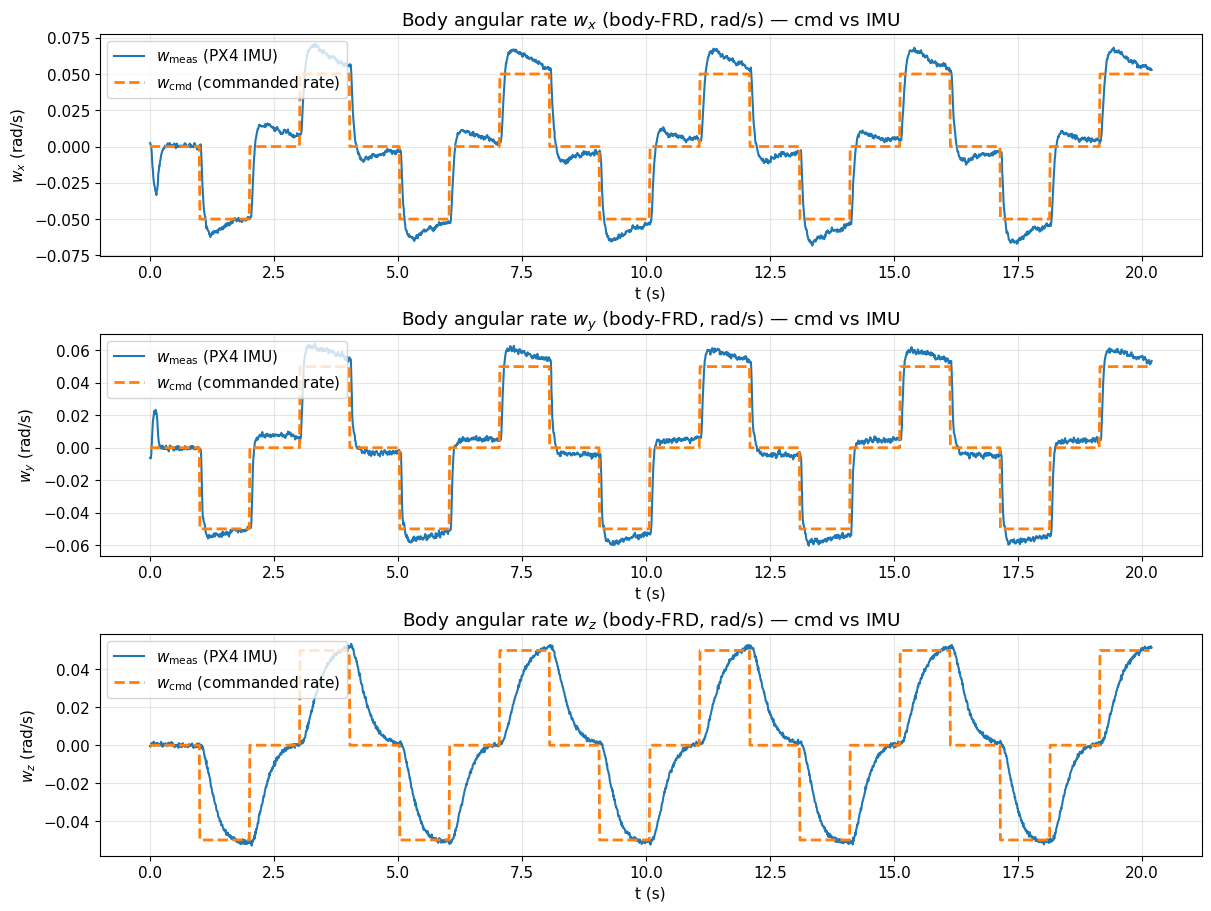

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
for i, (ax, name) in enumerate(zip(axes, ['x', 'y', 'z'])):
    ax.plot(t_a, w_t[:, i], label=r'$w_{\mathrm{meas}}$ (PX4 IMU)')
    ax.plot(t_g, w_u[:, i], label=r'$w_{\mathrm{cmd}}$ (commanded rate)',
             linestyle='--', linewidth=2)
    ax.set(title=f'Body angular rate $w_{name}$ (body-FRD, rad/s) — cmd vs IMU',
           xlabel='t (s)', ylabel=f'$w_{name}$ (rad/s)')
    ax.legend()
plt.show()

### Body thrust — the 4th commanded input (commanded vs achieved a_z)

Total body thrust from the IMU: thrust acts along body −z, so the specific-force down-component is `a_down = −T/m` ⇒ `T_t = −mass · a_down` (≈ `m·g` ≈ 20.7 N at hover). Compared against commanded **total** thrust `mass·g − T_u` — the command logs a hover-*delta* `T_u` (col 3), where **+`T_u` = less thrust** (see `convert_2_sys_cmd`), so total thrust = `m·g − T_u`.

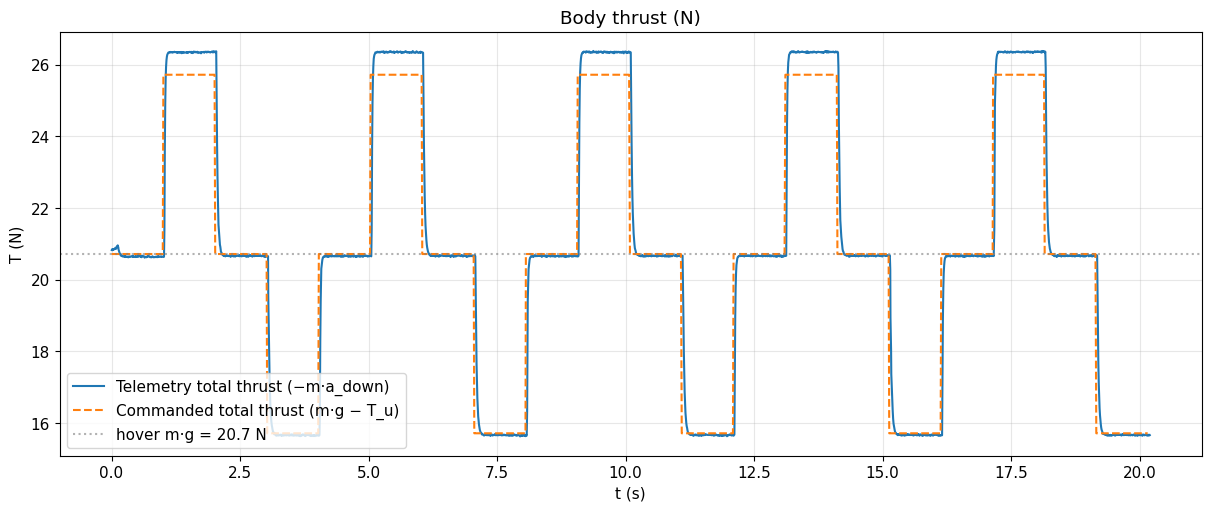

In [11]:
plt.figure(figsize=(12, 5), constrained_layout=True)
plt.plot(t_a, T_t, label='Telemetry total thrust (−m·a_down)')
plt.plot(t_g, mass*g_scalar - T_u, label='Commanded total thrust (m·g − T_u)',
         linestyle='--')
plt.axhline(mass*g_scalar, color='grey', linestyle=':', alpha=0.6,
            label=f'hover m·g = {mass*g_scalar:.1f} N')
plt.title('Body thrust (N)')
plt.xlabel('t (s)'); plt.ylabel('T (N)')
plt.legend(); plt.show()

### Command → response quality

Per-axis Pearson correlation between commanded virtual image angular velocity `w_cmd` and IMU-measured `w_meas` (= manuscript `w`), computed only where the command is non-zero (so idle hover periods don't dominate the metric). Plus thrust command vs IMU-derived thrust.

In [12]:
# Resample command onto IMU timeline
w_u_on_imu = np.array([np.interp(t_a, t_g, w_u[:, i]) for i in range(3)]).T
T_u_on_imu = np.interp(t_a, t_g, T_u)

def corr_active(meas, cmd, threshold):
    m = np.abs(cmd) > threshold
    if m.sum() < 10: return float('nan')
    c = np.corrcoef(meas[m], cmd[m])[0, 1]
    return c

# w_meas (IMU) vs w_cmd correlation per axis — manuscript w = virtual image angular velocity.
print('Body angular rate w_cmd vs w_meas (IMU) — only where |w_cmd| > 0.01 rad/s:')
for i, name in enumerate(['w_x', 'w_y', 'w_z']):
    c = corr_active(w_t[:, i], w_u_on_imu[:, i], 0.01)
    rmse = np.sqrt(np.nanmean((w_t[:, i] - w_u_on_imu[:, i])**2))
    print(f'  {name}: corr={c:+.3f}  RMSE={rmse:.4f} rad/s')

# Total thrust: IMU-derived (−m·a_down) vs commanded total (m·g − T_u),
# evaluated only where the thrust command is active (|T_u| > 0.1 N).
print('\nTotal thrust: IMU-derived vs commanded (m·g − T_u), where |T_u| > 0.1 N:')
T_cmd_total = mass*g_scalar - T_u_on_imu
m = np.abs(T_u_on_imu) > 0.1
if m.sum() >= 10:
    c = np.corrcoef(T_t[m], T_cmd_total[m])[0, 1]
    rmse = np.sqrt(np.nanmean((T_t[m] - T_cmd_total[m])**2))
else:
    c = rmse = float('nan')
print(f'  T: corr={c:+.3f}  RMSE={rmse:.4f} N   (hover T_t ≈ {mass*g_scalar:.2f} N)')

Body angular rate w_cmd vs w_meas (IMU) — only where |w_cmd| > 0.01 rad/s:
  w_x: corr=+0.973  RMSE=0.0139 rad/s
  w_y: corr=+0.980  RMSE=0.0115 rad/s
  w_z: corr=+0.894  RMSE=0.0232 rad/s

Total thrust: IMU-derived vs commanded (m·g − T_u), where |T_u| > 0.1 N:
  T: corr=+0.983  RMSE=1.0122 N   (hover T_t ≈ 20.72 N)


## §3 — Supporting diagnostics

Position, attitude (Euler), PX4-EKF-yaw-vs-GT drift, linear velocity, acceleration, thrust —
context for the transfer above, not the headline.

### Position (body frame)

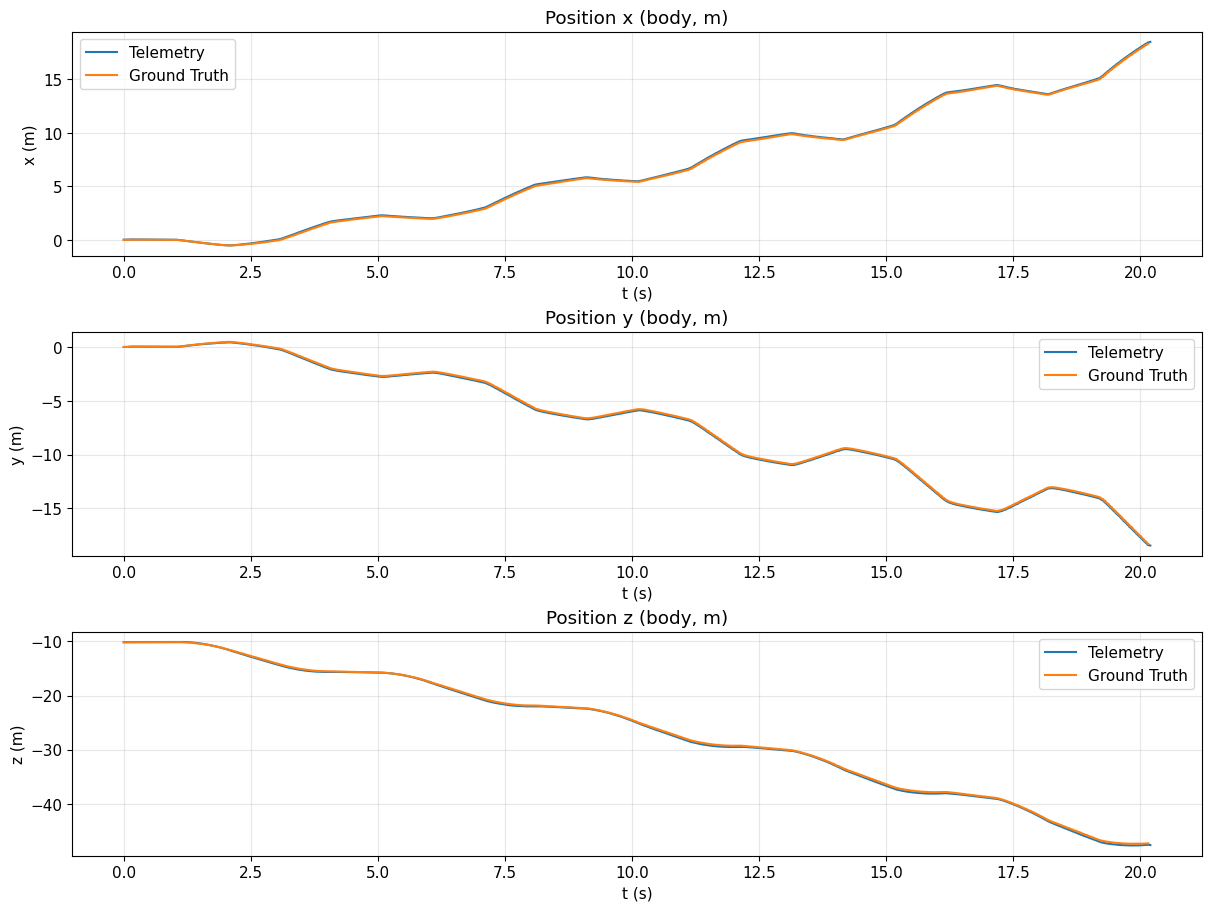

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
for i, (ax, name) in enumerate(zip(axes, ['x', 'y', 'z'])):
    ax.plot(t_o, B_x_ut[:, i], label='Telemetry')
    ax.plot(t_g, B_x_ug[:, i], label='Ground Truth')
    ax.set(title=f'Position {name} (body, m)', xlabel='t (s)', ylabel=f'{name} (m)')
    ax.legend()
plt.show()

### Euler angles

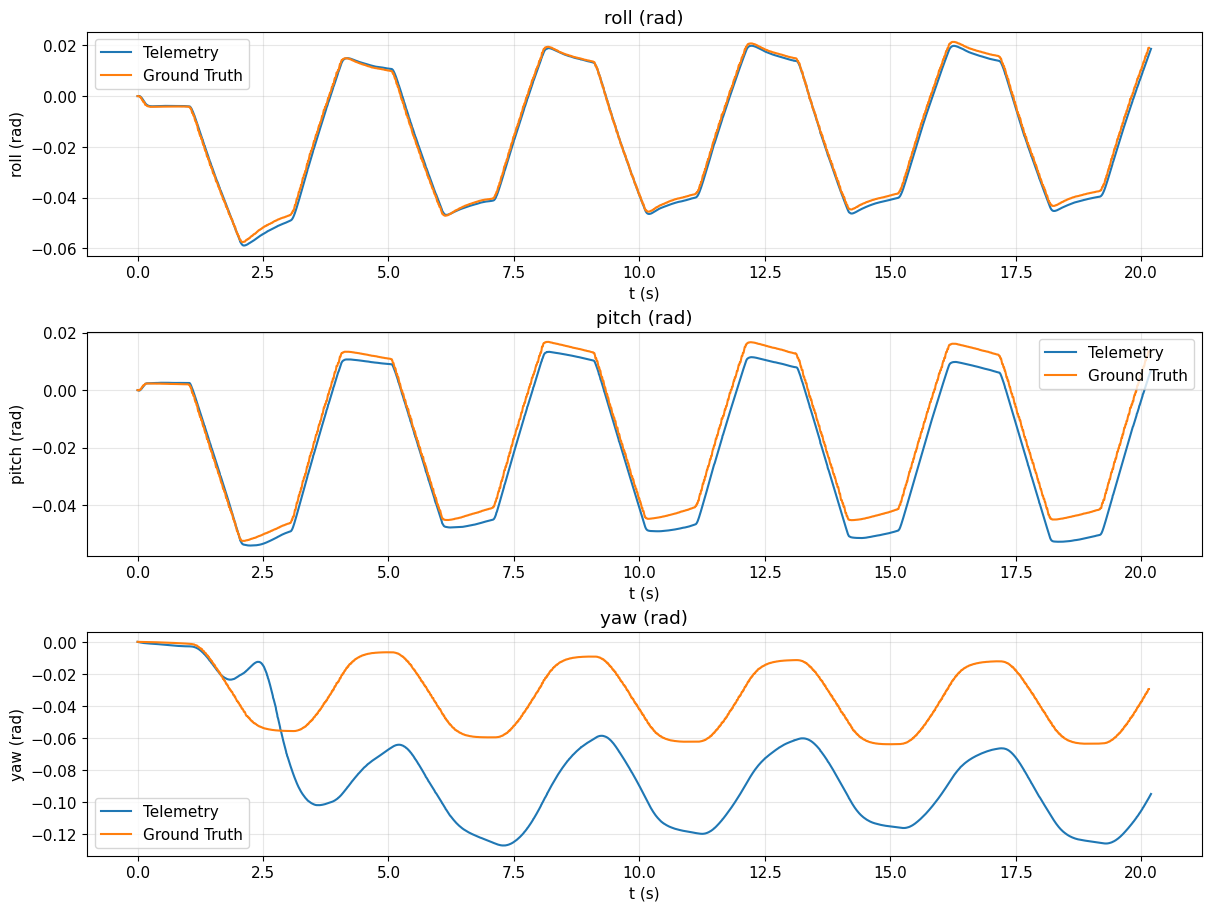

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
for i, (ax, name) in enumerate(zip(axes, ['roll', 'pitch', 'yaw'])):
    ax.plot(t_o, EA_t[:, i], label='Telemetry')
    ax.plot(t_g, EA_g[:, i], label='Ground Truth')
    ax.set(title=f'{name} (rad)', xlabel='t (s)', ylabel=f'{name} (rad)')
    ax.legend()
plt.show()

### PX4 EKF yaw vs GT yaw — drift during aggressive maneuvers

Both traces show yaw delta-from-spawn (the quaternion-correct form). Any divergence between them is PX4's EKF yaw-estimation error — it integrates gyro short-term but corrects slowly via magnetometer, so under sustained input-cal rate commands the EKF yaw drifts away from truth. This drift, multiplied by the drone's world-position magnitude, is what produces the body-frame position mismatch (see `BODY_YAW_SOURCE` cell).

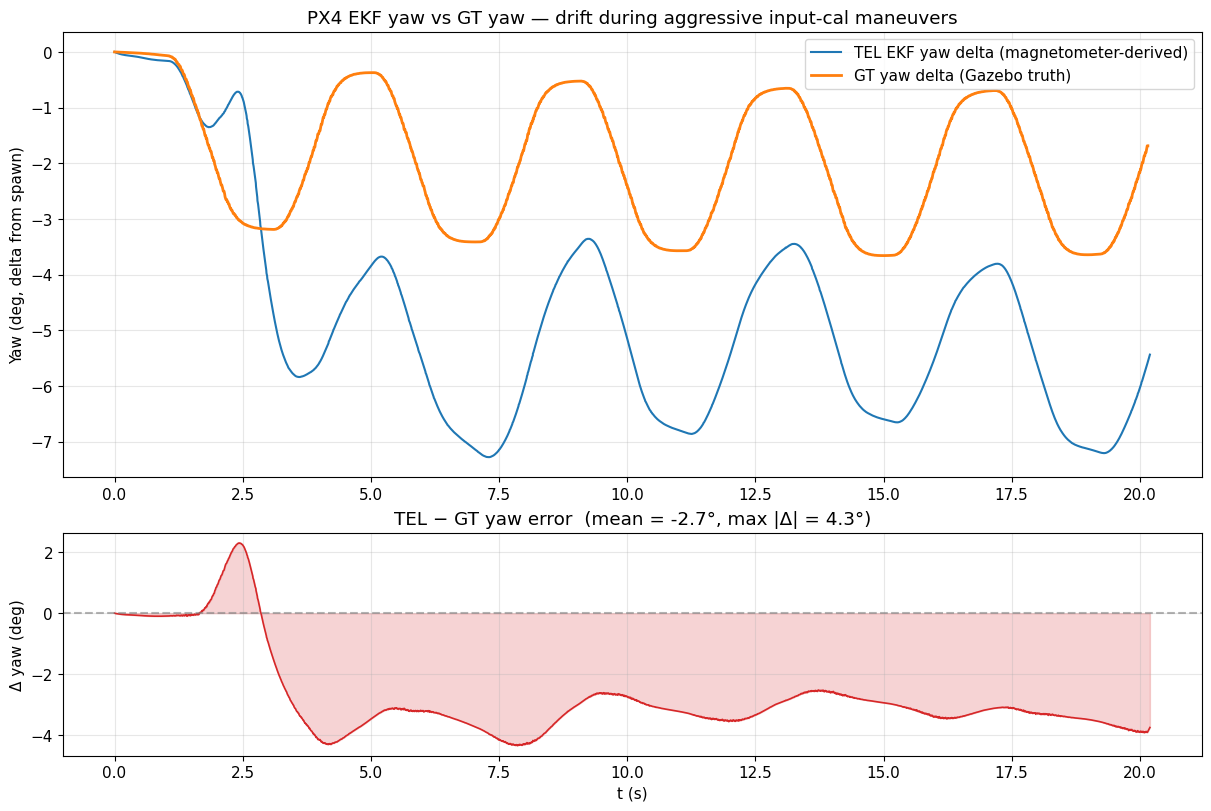

In [15]:
from scipy.interpolate import interp1d as _interp1d
# Interpolate GT yaw onto TEL timebase for per-sample error
_yg_at_o = _interp1d(t_g, EA_g[:, 2],
                     fill_value='extrapolate', bounds_error=False)(t_o)
_err_deg = np.degrees(EA_t[:, 2] - _yg_at_o)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True,
                          gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(t_o, np.degrees(EA_t[:, 2]),
              label='TEL EKF yaw delta (magnetometer-derived)',
              linewidth=1.5, color='tab:blue')
axes[0].plot(t_g, np.degrees(EA_g[:, 2]),
              label='GT yaw delta (Gazebo truth)',
              linewidth=2.0, color='tab:orange')
axes[0].set_title('PX4 EKF yaw vs GT yaw — drift during aggressive input-cal maneuvers')
axes[0].set_ylabel('Yaw (deg, delta from spawn)')
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(t_o, _err_deg, color='tab:red', linewidth=1.2)
axes[1].axhline(0, linestyle='--', color='grey', alpha=0.6)
axes[1].fill_between(t_o, 0, _err_deg, alpha=0.2, color='tab:red')
axes[1].set_title(
    f'TEL − GT yaw error  '
    f'(mean = {_err_deg.mean():+.1f}°, max |Δ| = {np.max(np.abs(_err_deg)):.1f}°)'
)
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('Δ yaw (deg)')
axes[1].grid(True, alpha=0.3)
plt.show()


### Linear velocity (body frame)

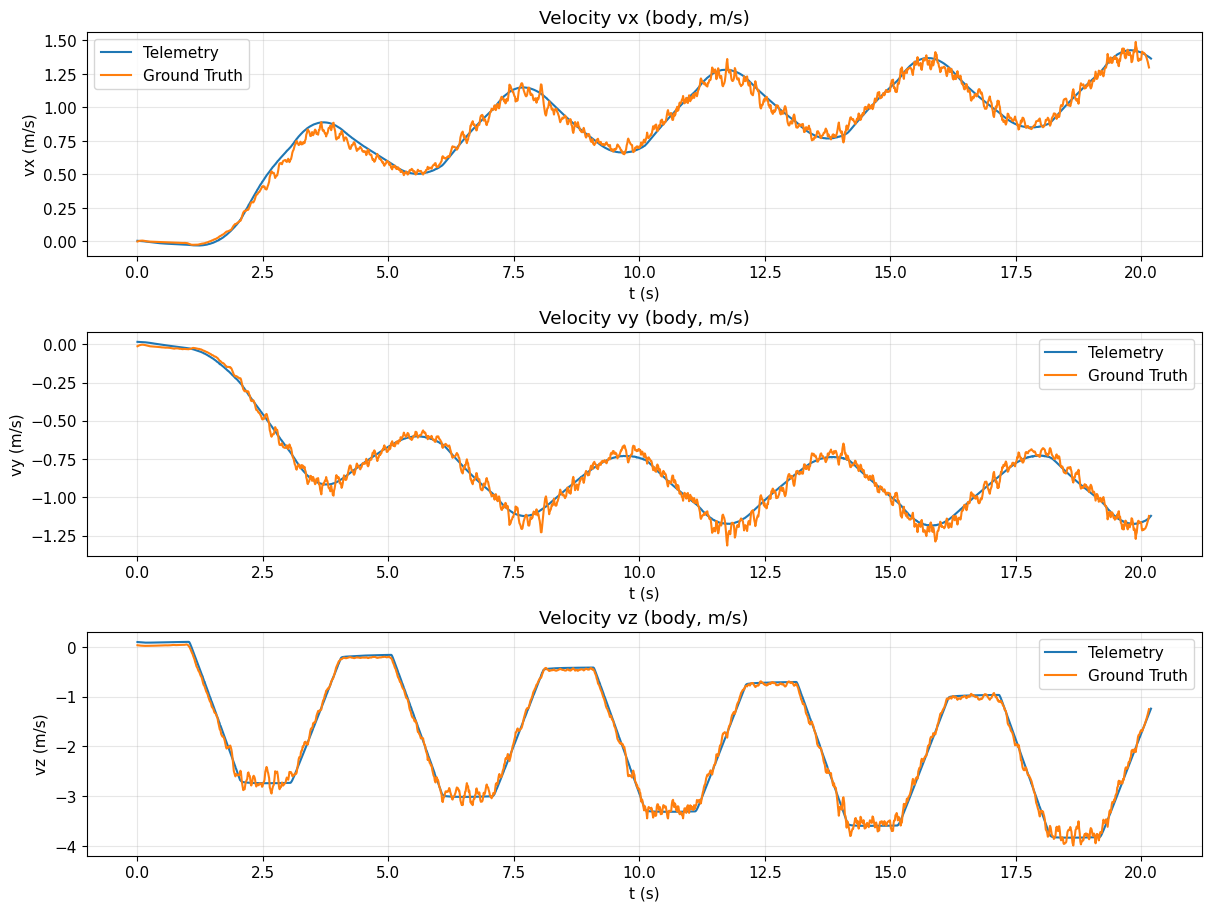

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
for i, (ax, name) in enumerate(zip(axes, ['vx', 'vy', 'vz'])):
    ax.plot(t_o, B_v_ut[:, i], label='Telemetry')
    ax.plot(t_g, B_v_ug[:, i], label='Ground Truth')
    ax.set(title=f'Velocity {name} (body, m/s)', xlabel='t (s)', ylabel=f'{name} (m/s)')
    ax.legend()
plt.show()

### Linear acceleration

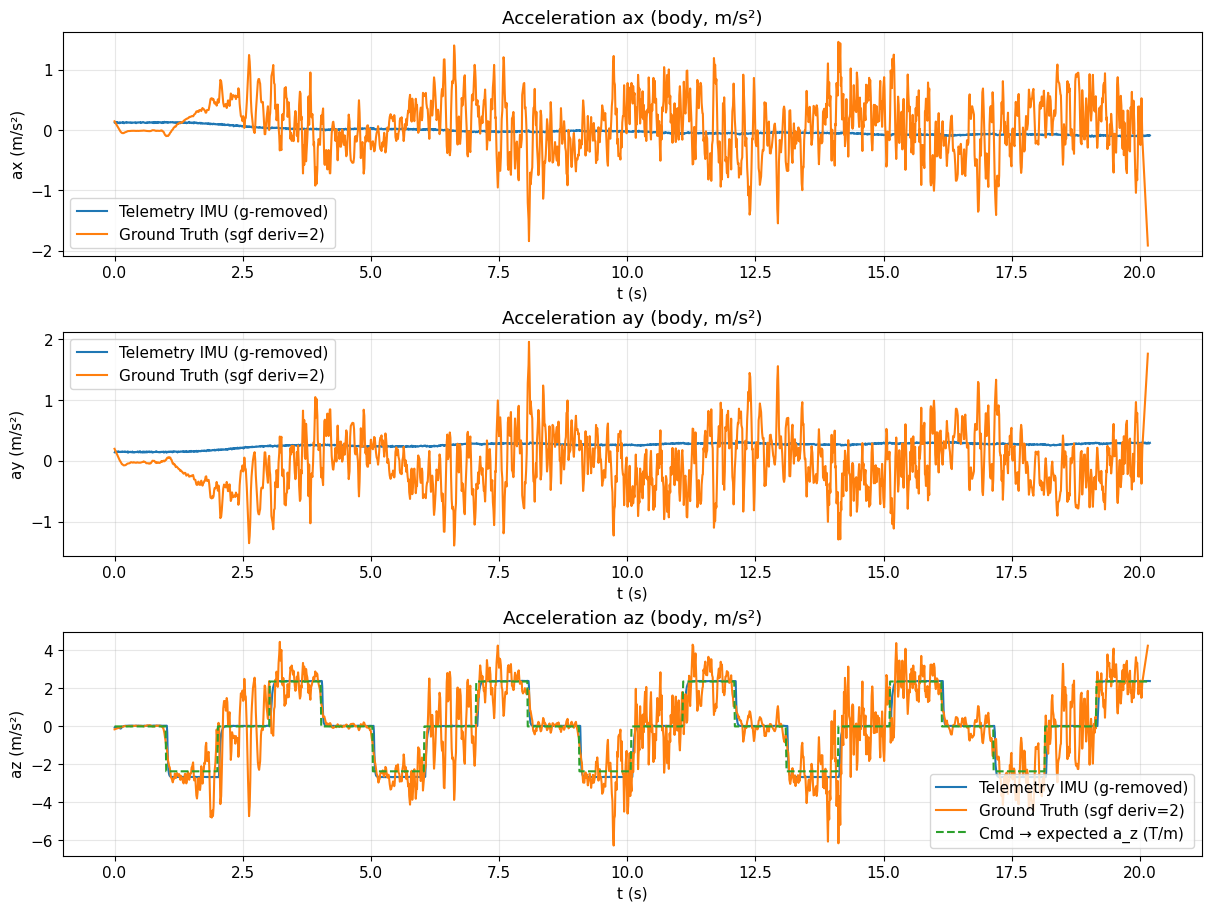

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
g_vec = [0, 0, g_scalar]
for i, (ax, name) in enumerate(zip(axes, ['ax', 'ay', 'az'])):
    # IMU specific force is a_kin - g_in_body. To recover kinematic accel:
    # a_kin = a_specific + g_in_body. (Previous formula `-a_t[i] - g_vec[i]`
    # equals `-a_kin` — coincidentally 0 at hover, sign-flipped everywhere else.)
    ax.plot(t_a, a_t[:, i] + g_vec[i], label='Telemetry IMU (g-removed)')
    ax.plot(t_g, B_a_ug[:, i], label='Ground Truth (sgf deriv=2)')
    if i == 2:
        # T_u is the controller's B_T in Newtons (from src/controller.py:850
        # = mass · (I_a[2] + g) / cos·cos). 1 N of B_T physically produces
        # 1/mass m/s² of body-z accel (Newton's law). The empirical
        # 0.738/45 mapping in convert_2_sys_cmd was tuned so the closed-loop
        # FC response approximates this physical relationship within ~6%.
        # Verified empirically on n=7 input-cal runs: TEL/T_u_per_mass gain
        # = 0.937 ± 0.05, r = 0.995, lag = 36 ms.
        #
        # Positive T_u → less thrust → drone falls → +a_z in FRD (down).
        a_z_cmd = T_u / mass
        ax.plot(t_g, a_z_cmd, label='Cmd → expected a_z (T/m)', linestyle='--')
    ax.set(title=f'Acceleration {name} (body, m/s²)',
           xlabel='t (s)', ylabel=f'{name} (m/s²)')
    ax.legend()
plt.show()